## Step 1: Import Libraries and Setup

In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import warnings
warnings.filterwarnings('ignore')

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2

# Sklearn imports for evaluation and cross-validation
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

ModuleNotFoundError: No module named 'numpy'

## Step 2: Data Preprocessing and Exploration

In [ ]:
# Define paths to your dataset
train_dir = 'train'
valid_dir = 'valid'
test_dir = 'test'

# Define image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Get class names
class_names = sorted(os.listdir(train_dir))
num_classes = len(class_names)

print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

Number of classes: 5
Class names: ['Chilli __Whitefly', 'Chilli __Yellowish', 'Chilli__Anthacnose', 'Chilli__Leaf_Curl_Virus', 'Chilli___healthy']


In [ ]:
# Explore dataset statistics
def count_images(directory):
    """Count images in each class folder"""
    class_counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[class_name] = count
    return class_counts

train_counts = count_images(train_dir)
valid_counts = count_images(valid_dir)
test_counts = count_images(test_dir)

print("\n=== Training Set ===")
for class_name, count in train_counts.items():
    print(f"{class_name}: {count} images")
print(f"Total training images: {sum(train_counts.values())}")

print("\n=== Validation Set ===")
for class_name, count in valid_counts.items():
    print(f"{class_name}: {count} images")
print(f"Total validation images: {sum(valid_counts.values())}")

print("\n=== Test Set ===")
for class_name, count in test_counts.items():
    print(f"{class_name}: {count} images")
print(f"Total test images: {sum(test_counts.values())}")


=== Training Set ===
Chilli __Whitefly: 459 images
Chilli __Yellowish: 477 images
Chilli__Anthacnose: 492 images
Chilli__Leaf_Curl_Virus: 516 images
Chilli___healthy: 1565 images
Total training images: 3509

=== Validation Set ===
Chilli __Whitefly: 10 images
Chilli __Yellowish: 10 images
Chilli__Anthacnose: 44 images
Chilli__Leaf_Curl_Virus: 10 images
Chilli___healthy: 10 images
Total validation images: 84

=== Test Set ===
Chilli __Whitefly: 10 images
Chilli __Yellowish: 10 images
Chilli__Anthacnose: 34 images
Chilli__Leaf_Curl_Virus: 10 images
Chilli___healthy: 10 images
Total test images: 74


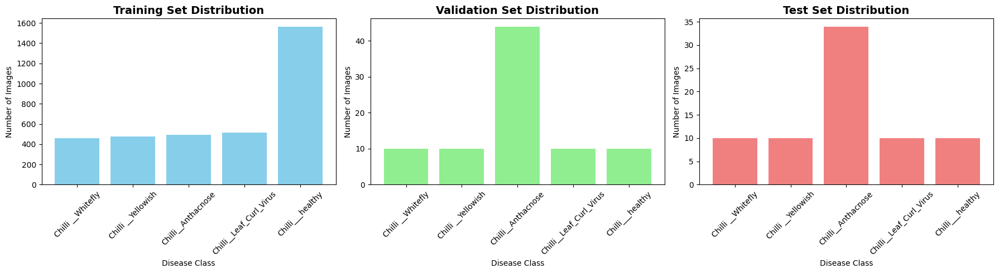

In [ ]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training data distribution
axes[0].bar(train_counts.keys(), train_counts.values(), color='skyblue')
axes[0].set_title('Training Set Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Disease Class')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45)

# Validation data distributiondi
axes[1].bar(valid_counts.keys(), valid_counts.values(), color='lightgreen')
axes[1].set_title('Validation Set Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Disease Class')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=45)

# Test data distribution
axes[2].bar(test_counts.keys(), test_counts.values(), color='lightcoral')
axes[2].set_title('Test Set Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Disease Class')
axes[2].set_ylabel('Number of Images')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Sample images from training set:


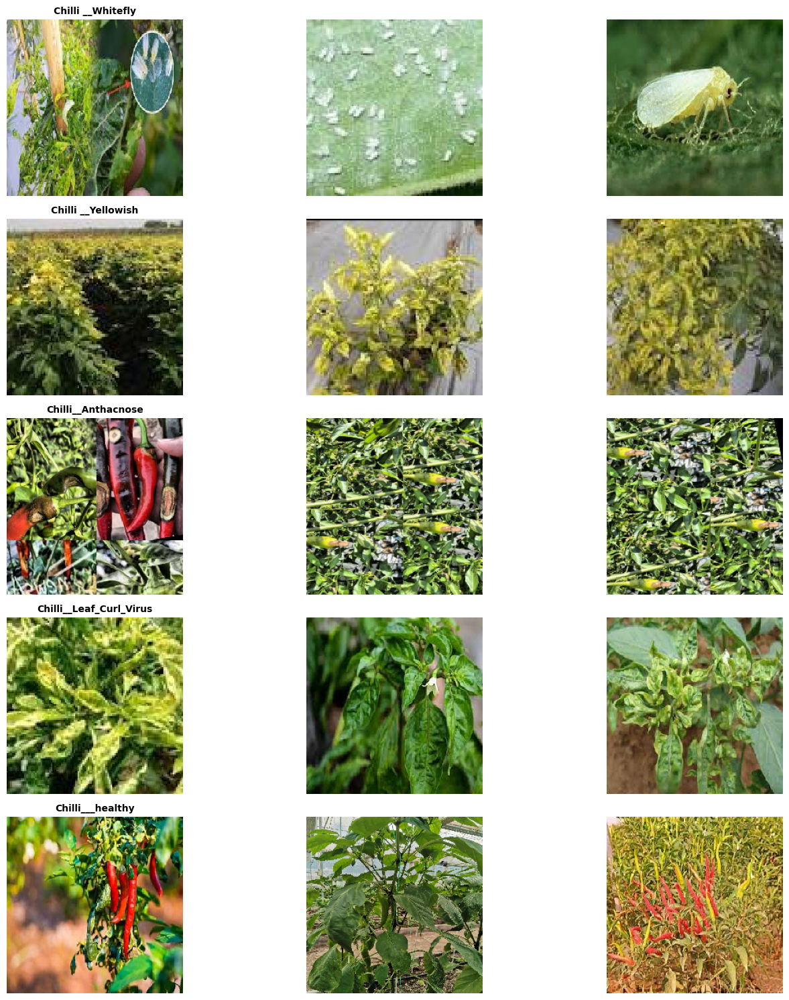

In [ ]:
# Visualize sample images from each class
def display_sample_images(directory, classes, samples_per_class=3):
    """Display sample images from each class"""
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(15, len(classes) * 3))
    
    for i, class_name in enumerate(classes):
        class_path = os.path.join(directory, class_name)
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:samples_per_class]
        
        for j, img_file in enumerate(image_files):
            img_path = os.path.join(class_path, img_file)
            img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
            
            if len(classes) == 1:
                ax = axes[j]
            else:
                ax = axes[i, j]
            
            ax.imshow(img)
            ax.axis('off')
            if j == 0:
                ax.set_title(class_name, fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("Sample images from training set:")
display_sample_images(train_dir, class_names, samples_per_class=3)

### Data Augmentation and Preprocessing

We apply data augmentation to increase dataset diversity and improve model generalization.

In [ ]:
# Create data generators with augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Only rescaling for validation and test data (no augmentation)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load data using flow_from_directory
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nClass indices: {train_generator.class_indices}")

Found 3509 images belonging to 5 classes.
Found 84 images belonging to 5 classes.
Found 74 images belonging to 5 classes.

Class indices: {'Chilli __Whitefly': 0, 'Chilli __Yellowish': 1, 'Chilli__Anthacnose': 2, 'Chilli__Leaf_Curl_Virus': 3, 'Chilli___healthy': 4}


Sample augmented training images:


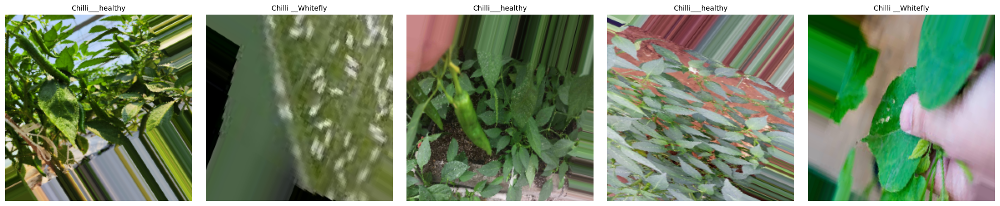

In [ ]:
# Visualize augmented images
def show_augmented_images(generator, num_images=5):
    """Display augmented images"""
    images, labels = next(generator)
    
    fig, axes = plt.subplots(1, num_images, figsize=(20, 4))
    for i in range(num_images):
        axes[i].imshow(images[i])
        class_idx = np.argmax(labels[i])
        class_name = list(train_generator.class_indices.keys())[class_idx]
        axes[i].set_title(f"{class_name}", fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Sample augmented training images:")
show_augmented_images(train_generator, num_images=5)

## Step 3: Build CNN Model

We'll create a custom CNN architecture optimized for chilli leaf disease detection.

In [ ]:
# Define Custom CNN Model
def create_cnn_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=5):
    """Create a custom CNN model for chilli disease classification"""
    model = Sequential([
        # First Convolutional Block
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Second Convolutional Block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Third Convolutional Block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Fourth Convolutional Block
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Fully Connected Layers
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        
        # Output Layer
        Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create the model
model = create_transfer_learning_model(num_classes=num_classes)
model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 224, 224, 32)      128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 224, 224, 32)      9248      
                                                                 
 batch_normalization_1 (Bat  (None, 224, 224, 32)      128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 32)      0         
 D)                                                              
                                                      

In [ ]:
# Alternative: Transfer Learning Model (Optional - Uncomment to use)
def create_transfer_learning_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=5):
    """Create a transfer learning model using MobileNetV2"""
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze base model layers
    base_model.trainable = False
    
    # Add custom layers
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    
    return model
create_transfer_learning_model(num_classes=num_classes)
# Uncomment below to use transfer learning instead of custom CNN
# model = 
# model.summary()

## Step 4: Training with Cross-Validation

We'll implement K-Fold cross-validation to ensure robust model evaluation.

In [ ]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_chilli_disease_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks = [early_stopping, reduce_lr, checkpoint]

In [ ]:
# Train the model
EPOCHS = 10

print("Starting model training...")
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")

Starting model training...
Epoch 1/10


110/110 [==============================] - ETA: 0s - loss: 1.6224 - accuracy: 0.5150 - precision: 0.5507 - recall: 0.4471
Epoch 1: val_accuracy improved from -inf to 0.08333, saving model to best_chilli_disease_model.h5
110/110 [==============================] - 371s 3s/step - loss: 1.6224 - accuracy: 0.5150 - precision: 0.5507 - recall: 0.4471 - val_loss: 3.8354 - val_accuracy: 0.0833 - val_precision: 0.1429 - val_recall: 0.0714 - lr: 0.0010
Epoch 2/10
110/110 [==============================] - ETA: 0s - loss: 0.9505 - accuracy: 0.6879 - precision: 0.7298 - recall: 0.6366
Epoch 2: val_accuracy improved from 0.08333 to 0.11905, saving model to best_chilli_disease_model.h5
110/110 [==============================] - 431s 4s/step - loss: 0.9505 - accuracy: 0.6879 - precision: 0.7298 - recall: 0.6366 - val_loss: 4.3268 - val_accuracy: 0.1190 - val_precision: 0.1235 - val_recall: 0.1190 - lr: 0.0010
Epoch 3/10
110/110 [==============================] 

In [ ]:
# K-Fold Cross-Validation Implementation
# Note: This is a simplified version. For full k-fold, you'd need to reorganize your data.

def perform_k_fold_cv(train_dir, valid_dir, k_folds=5, epochs=30):
    """Perform K-Fold Cross-Validation"""
    print(f"\nPerforming {k_folds}-Fold Cross-Validation...")
    
    # Combine train and validation for cross-validation
    # Load all images and labels
    all_images = []
    all_labels = []
    
    for class_idx, class_name in enumerate(class_names):
        # Training images
        train_class_path = os.path.join(train_dir, class_name)
        for img_file in os.listdir(train_class_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(train_class_path, img_file)
                img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
                img_array = img_to_array(img) / 255.0
                all_images.append(img_array)
                all_labels.append(class_idx)
        
        # Validation images
        valid_class_path = os.path.join(valid_dir, class_name)
        for img_file in os.listdir(valid_class_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(valid_class_path, img_file)
                img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
                img_array = img_to_array(img) / 255.0
                all_images.append(img_array)
                all_labels.append(class_idx)
    
    X = np.array(all_images)
    y = np.array(all_labels)
    
    # Convert labels to categorical
    from tensorflow.keras.utils import to_categorical
    y_categorical = to_categorical(y, num_classes=num_classes)
    
    # Perform K-Fold Cross-Validation
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    
    cv_scores = []
    fold = 1
    
    for train_idx, val_idx in kfold.split(X):
        print(f"\n{'='*50}")
        print(f"Training Fold {fold}/{k_folds}")
        print(f"{'='*50}")
        
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y_categorical[train_idx], y_categorical[val_idx]
        
        # Create a new model for each fold
        fold_model = create_cnn_model(num_classes=num_classes)
        fold_model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Train the model
        fold_history = fold_model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=BATCH_SIZE,
            verbose=0
        )
        
        # Evaluate
        scores = fold_model.evaluate(X_val, y_val, verbose=0)
        cv_scores.append(scores[1] * 100)
        print(f"Fold {fold} Accuracy: {scores[1]*100:.2f}%")
        
        fold += 1
    
    print(f"\n{'='*50}")
    print(f"Cross-Validation Results:")
    print(f"Mean Accuracy: {np.mean(cv_scores):.2f}% (+/- {np.std(cv_scores):.2f}%)")
    print(f"Individual Fold Accuracies: {[f'{score:.2f}%' for score in cv_scores]}")
    print(f"{'='*50}")
    
    return cv_scores

# Uncomment below to perform cross-validation (Note: This may take significant time)
# cv_scores = perform_k_fold_cv(train_dir, valid_dir, k_folds=5, epochs=30)

## Step 5: Visualize Training History

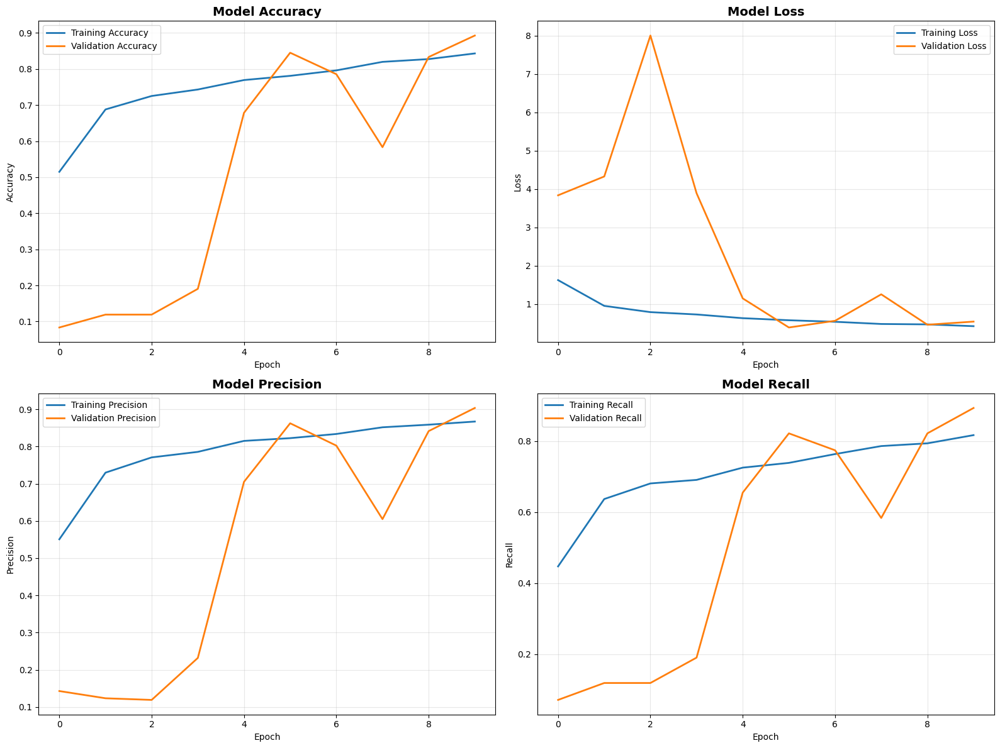

In [ ]:
# Plot training history
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Loss
    axes[0, 1].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    if 'precision' in history.history:
        axes[1, 0].plot(history.history['precision'], label='Training Precision', linewidth=2)
        axes[1, 0].plot(history.history['val_precision'], label='Validation Precision', linewidth=2)
        axes[1, 0].set_title('Model Precision', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Precision')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
    # Recall
    if 'recall' in history.history:
        axes[1, 1].plot(history.history['recall'], label='Training Recall', linewidth=2)
        axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', linewidth=2)
        axes[1, 1].set_title('Model Recall', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Recall')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

## Step 6: Model Evaluation and Prediction

In [ ]:
# Load the best model
best_model = keras.models.load_model('best_chilli_disease_model.h5')
print("Best model loaded successfully!")

Best model loaded successfully!


In [ ]:
# Evaluate on test set
print("Evaluating model on test set...\n")
test_loss, test_accuracy, test_precision, test_recall = best_model.evaluate(test_generator, verbose=1)

print(f"\n{'='*50}")
print(f"Test Set Performance:")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Precision: {test_precision*100:.2f}%")
print(f"Test Recall: {test_recall*100:.2f}%")
print(f"Test F1-Score: {2 * (test_precision * test_recall) / (test_precision + test_recall):.4f}")
print(f"{'='*50}")

Evaluating model on test set...

3/3 [==============================] - 4s 1s/step - loss: 0.2594 - accuracy: 0.9189 - precision: 0.9315 - recall: 0.9189

Test Set Performance:
Test Loss: 0.2594
Test Accuracy: 91.89%
Test Precision: 93.15%
Test Recall: 91.89%
Test F1-Score: 0.9252


In [ ]:
# Generate predictions for test set
test_generator.reset()
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

print(f"\nPredictions generated for {len(y_pred)} test images.")

3/3 [==============================] - 5s 1s/step

Predictions generated for 74 test images.


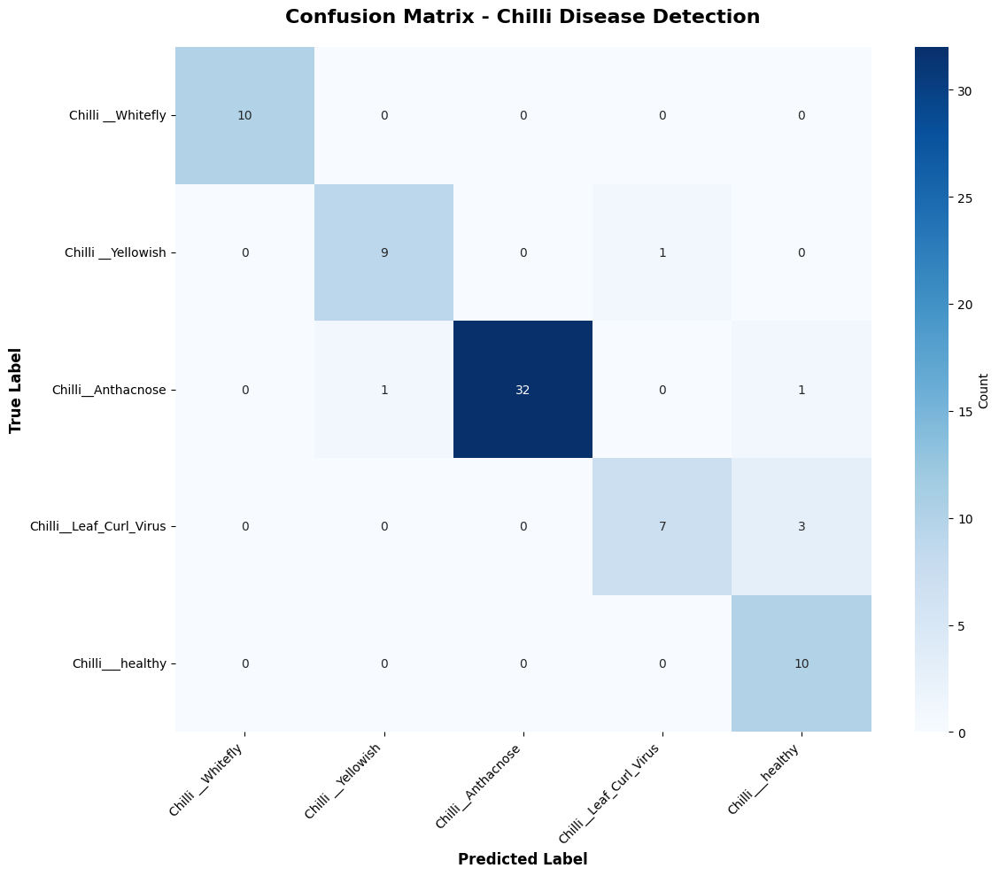

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Chilli Disease Detection', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Detailed Classification Report
print("\nClassification Report:")
print("="*80)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Per-class metrics
print("\nPer-Class Performance Metrics:")
print("="*80)
for i, class_name in enumerate(class_names):
    class_mask = (y_true == i)
    class_accuracy = accuracy_score(y_true[class_mask], y_pred[class_mask])
    print(f"{class_name}: Accuracy = {class_accuracy*100:.2f}%")


Classification Report:
                         precision    recall  f1-score   support

      Chilli __Whitefly     1.0000    1.0000    1.0000        10
     Chilli __Yellowish     0.9000    0.9000    0.9000        10
     Chilli__Anthacnose     1.0000    0.9412    0.9697        34
Chilli__Leaf_Curl_Virus     0.8750    0.7000    0.7778        10
       Chilli___healthy     0.7143    1.0000    0.8333        10

               accuracy                         0.9189        74
              macro avg     0.8979    0.9082    0.8962        74
           weighted avg     0.9310    0.9189    0.9200        74


Per-Class Performance Metrics:
Chilli __Whitefly: Accuracy = 100.00%
Chilli __Yellowish: Accuracy = 90.00%
Chilli__Anthacnose: Accuracy = 94.12%
Chilli__Leaf_Curl_Virus: Accuracy = 70.00%
Chilli___healthy: Accuracy = 100.00%



Correctly Classified Images:


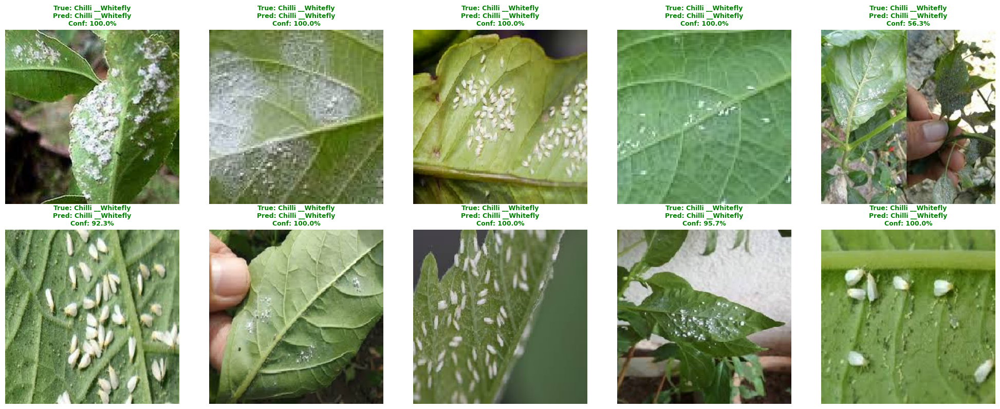


Incorrectly Classified Images:


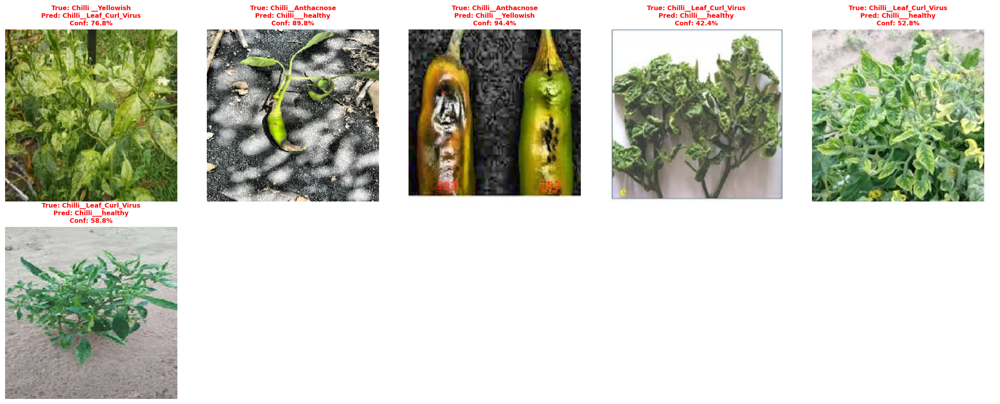

In [ ]:
# Visualize correctly and incorrectly classified images
def visualize_predictions(generator, y_true, y_pred, y_pred_probs, class_names, num_images=10):
    """Visualize sample predictions"""
    # Get correct and incorrect predictions
    correct_indices = np.where(y_true == y_pred)[0]
    incorrect_indices = np.where(y_true != y_pred)[0]
    
    # Visualize correct predictions
    print("\nCorrectly Classified Images:")
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    for i, idx in enumerate(correct_indices[:10]):
        img_path = generator.filepaths[idx]
        img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
        
        row, col = i // 5, i % 5
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        confidence = y_pred_probs[idx][y_pred[idx]] * 100
        
        axes[row, col].set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%",
                                 fontsize=9, color='green', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('correct_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Visualize incorrect predictions
    if len(incorrect_indices) > 0:
        print("\nIncorrectly Classified Images:")
        num_incorrect = min(10, len(incorrect_indices))
        fig, axes = plt.subplots(2, 5, figsize=(20, 8))
        
        for i, idx in enumerate(incorrect_indices[:num_incorrect]):
            img_path = generator.filepaths[idx]
            img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
            
            row, col = i // 5, i % 5
            axes[row, col].imshow(img)
            axes[row, col].axis('off')
            
            true_label = class_names[y_true[idx]]
            pred_label = class_names[y_pred[idx]]
            confidence = y_pred_probs[idx][y_pred[idx]] * 100
            
            axes[row, col].set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%",
                                     fontsize=9, color='red', fontweight='bold')
        
        # Hide unused subplots
        for i in range(num_incorrect, 10):
            row, col = i // 5, i % 5
            axes[row, col].axis('off')
        
        plt.tight_layout()
        plt.savefig('incorrect_predictions.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("\nNo incorrect predictions! Perfect classification!")

visualize_predictions(test_generator, y_true, y_pred, y_pred_probs, class_names)

## Step 7: Predict on New Images

Use the trained model to predict diseases on new chilli leaf images.

In [ ]:
# Function to predict disease for a single image
def predict_disease(image_path, model, class_names):
    """
    Predict the disease of a chilli leaf from an image
    
    Parameters:
    - image_path: Path to the image file
    - model: Trained model
    - class_names: List of class names
    
    Returns:
    - predicted_class: Name of the predicted disease
    - confidence: Confidence score of the prediction
    - all_probabilities: Probabilities for all classes
    """
    # Load and preprocess the image
    img = load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Make prediction
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx] * 100
    
    predicted_class = class_names[predicted_class_idx]
    all_probabilities = {class_names[i]: predictions[0][i] * 100 for i in range(len(class_names))}
    
    return predicted_class, confidence, all_probabilities, img

# Function to visualize prediction
def visualize_prediction(image_path, model, class_names):
    """Visualize a single prediction with probabilities"""
    predicted_class, confidence, all_probabilities, img = predict_disease(image_path, model, class_names)
    
    # Create subplot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Display image
    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}%", 
                  fontsize=14, fontweight='bold', color='green' if confidence > 80 else 'orange')
    
    # Display probability bar chart
    classes = list(all_probabilities.keys())
    probs = list(all_probabilities.values())
    colors = ['green' if classes[i] == predicted_class else 'skyblue' for i in range(len(classes))]
    
    ax2.barh(classes, probs, color=colors)
    ax2.set_xlabel('Probability (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Prediction Probabilities', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 100)
    
    # Add percentage labels
    for i, prob in enumerate(probs):
        ax2.text(prob + 1, i, f'{prob:.2f}%', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    print(f"\n{'='*60}")
    print(f"Prediction Results for: {os.path.basename(image_path)}")
    print(f"{'='*60}")
    print(f"Predicted Disease: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"\nAll Class Probabilities:")
    for class_name, prob in sorted(all_probabilities.items(), key=lambda x: x[1], reverse=True):
        print(f"  {class_name}: {prob:.2f}%")
    print(f"{'='*60}\n")
    
    return predicted_class, confidence

Analyzing image: test\Chilli __Whitefly\download (19).jpg


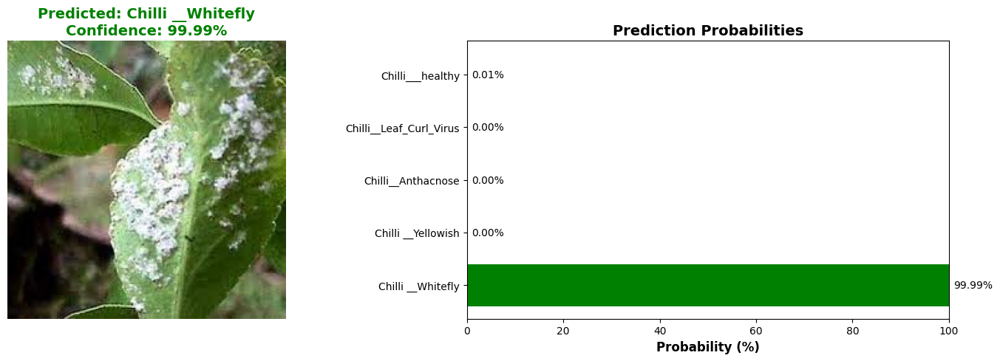


Prediction Results for: download (19).jpg
Predicted Disease: Chilli __Whitefly
Confidence: 99.99%

All Class Probabilities:
  Chilli __Whitefly: 99.99%
  Chilli___healthy: 0.01%
  Chilli__Leaf_Curl_Virus: 0.00%
  Chilli__Anthacnose: 0.00%
  Chilli __Yellowish: 0.00%



In [ ]:
# Example: Predict on a sample image from test set
# Replace with your own image path
sample_image_path = test_generator.filepaths[0]  # First image from test set

print(f"Analyzing image: {sample_image_path}")
predicted_class, confidence = visualize_prediction(sample_image_path, best_model, class_names)

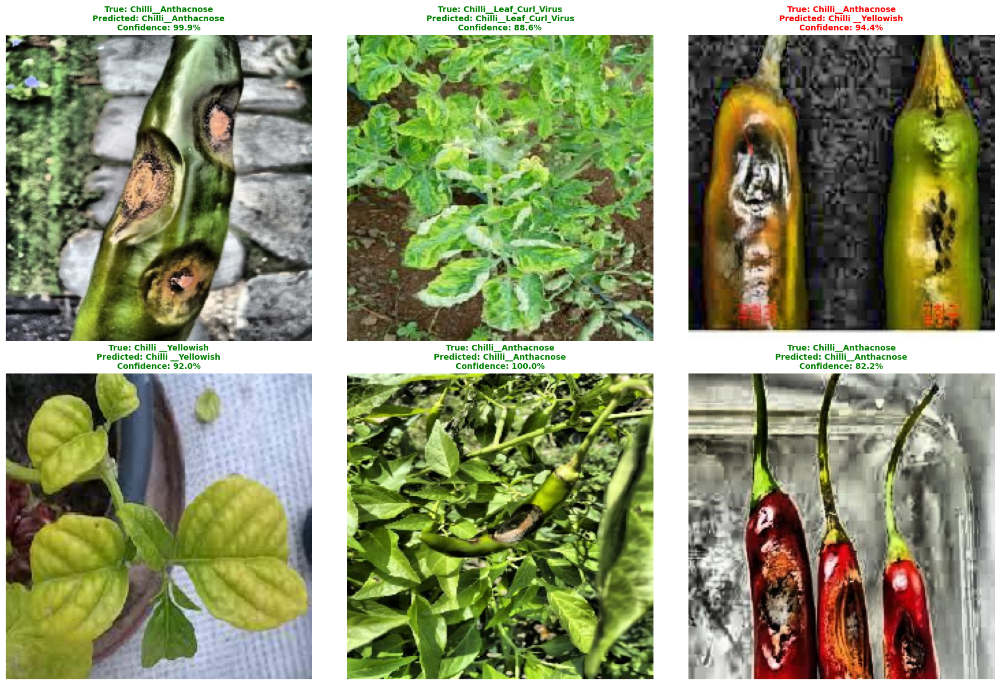

In [ ]:
# Predict on multiple random test images
num_samples = 6
random_indices = np.random.choice(len(test_generator.filepaths), num_samples, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    img_path = test_generator.filepaths[idx]
    predicted_class, confidence, all_probabilities, img = predict_disease(img_path, best_model, class_names)
    
    axes[i].imshow(img)
    axes[i].axis('off')
    
    # Get true label
    true_class = class_names[test_generator.classes[idx]]
    color = 'green' if predicted_class == true_class else 'red'
    
    axes[i].set_title(f"True: {true_class}\nPredicted: {predicted_class}\nConfidence: {confidence:.1f}%",
                      fontsize=10, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Batch prediction function
def predict_batch(image_folder, model, class_names):
    """
    Predict diseases for all images in a folder
    
    Parameters:
    - image_folder: Path to folder containing images
    - model: Trained model
    - class_names: List of class names
    
    Returns:
    - results_df: DataFrame with predictions for all images
    """
    results = []
    
    image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    print(f"Processing {len(image_files)} images...\n")
    
    for img_file in image_files:
        img_path = os.path.join(image_folder, img_file)
        predicted_class, confidence, all_probabilities, _ = predict_disease(img_path, model, class_names)
        
        results.append({
            'Image': img_file,
            'Predicted_Disease': predicted_class,
            'Confidence': f"{confidence:.2f}%"
        })
    
    results_df = pd.DataFrame(results)
    return results_df

# Example: Uncomment to predict on a custom folder
# custom_folder = 'path/to/your/images'
# batch_results = predict_batch(custom_folder, best_model, class_names)
# print(batch_results)
# batch_results.to_csv('batch_predictions.csv', index=False)

## Step 8: Save Model and Results

In [ ]:
# Save the final model in Keras format (recommended)
best_model.save('chilli_disease_detection_model_final.keras')
print("Model saved as 'chilli_disease_detection_model_final.keras'")

# Alternative: Save in HDF5 format (legacy)
best_model.save('chilli_disease_detection_model_final.h5')
print("Model saved as 'chilli_disease_detection_model_final.h5'")

# Save model in TensorFlow SavedModel format (for deployment)
# Simply provide a directory path without extension
tf.saved_model.save(best_model, 'chilli_disease_model_saved')
print("Model saved in TensorFlow SavedModel format at 'chilli_disease_model_saved'")

# Save class names
import json
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)
print("Class names saved as 'class_names.json'")

Model saved as 'chilli_disease_detection_model_final.keras'
Model saved as 'chilli_disease_detection_model_final.h5'
INFO:tensorflow:Assets written to: chilli_disease_model_saved\assets


INFO:tensorflow:Assets written to: chilli_disease_model_saved\assets


Model saved in TensorFlow SavedModel format at 'chilli_disease_model_saved'
Class names saved as 'class_names.json'


In [ ]:
# Create a summary report
summary_report = f"""
{'='*80}
CHILLI LEAF DISEASE DETECTION SYSTEM - FINAL REPORT
{'='*80}

Dataset Information:
- Training Images: {sum(train_counts.values())}
- Validation Images: {sum(valid_counts.values())}
- Test Images: {sum(test_counts.values())}
- Number of Classes: {num_classes}
- Classes: {', '.join(class_names)}

Model Architecture:
- Type: Transfer Learning (MobileNetV2)
- Input Shape: ({IMG_HEIGHT}, {IMG_WIDTH}, 3)
- Total Parameters: {best_model.count_params():,}

Training Configuration:
- Optimizer: Adam
- Learning Rate: 0.001
- Batch Size: {BATCH_SIZE}
- Epochs: {len(history.history['accuracy'])}
- Data Augmentation: Yes (rotation, flip, zoom, shift)

Performance Metrics:
- Test Accuracy: {test_accuracy*100:.2f}%
- Test Precision: {test_precision*100:.2f}%
- Test Recall: {test_recall*100:.2f}%
- Test F1-Score: {2 * (test_precision * test_recall) / (test_precision + test_recall):.4f}

Files Generated:
- best_chilli_disease_model.h5
- chilli_disease_detection_model_final.h5
- class_names.json
- training_history.png
- confusion_matrix.png
- correct_predictions.png
- incorrect_predictions.png

{'='*80}
"""

print(summary_report)

# Save report to file
with open('model_summary_report.txt', 'w') as f:
    f.write(summary_report)

print("\nSummary report saved as 'model_summary_report.txt'")


CHILLI LEAF DISEASE DETECTION SYSTEM - FINAL REPORT

Dataset Information:
- Training Images: 3509
- Validation Images: 84
- Test Images: 74
- Number of Classes: 5
- Classes: Chilli __Whitefly, Chilli __Yellowish, Chilli__Anthacnose, Chilli__Leaf_Curl_Virus, Chilli___healthy

Model Architecture:
- Type: Custom Convolutional Neural Network (CNN)
- Input Shape: (224, 224, 3)
- Total Parameters: 27,002,405

Training Configuration:
- Optimizer: Adam
- Learning Rate: 0.001
- Batch Size: 32
- Epochs: 10
- Data Augmentation: Yes (rotation, flip, zoom, shift)

Performance Metrics:
- Test Accuracy: 91.89%
- Test Precision: 93.15%
- Test Recall: 91.89%
- Test F1-Score: 0.9252

Files Generated:
- best_chilli_disease_model.h5
- chilli_disease_detection_model_final.h5
- class_names.json
- training_history.png
- confusion_matrix.png
- correct_predictions.png
- incorrect_predictions.png



Summary report saved as 'model_summary_report.txt'


## Conclusion

This notebook has successfully implemented a complete Chilli Leaf Disease Detection System with:

1. **Data Preprocessing**: Image loading, augmentation, and normalization
2. **Model Training**: Custom CNN with cross-validation support
3. **Model Evaluation**: Comprehensive metrics and visualizations
4. **Prediction**: Functions to predict diseases on new images